<a href="https://colab.research.google.com/github/saniya-ahuja/Double-descent-app/blob/main/Double_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

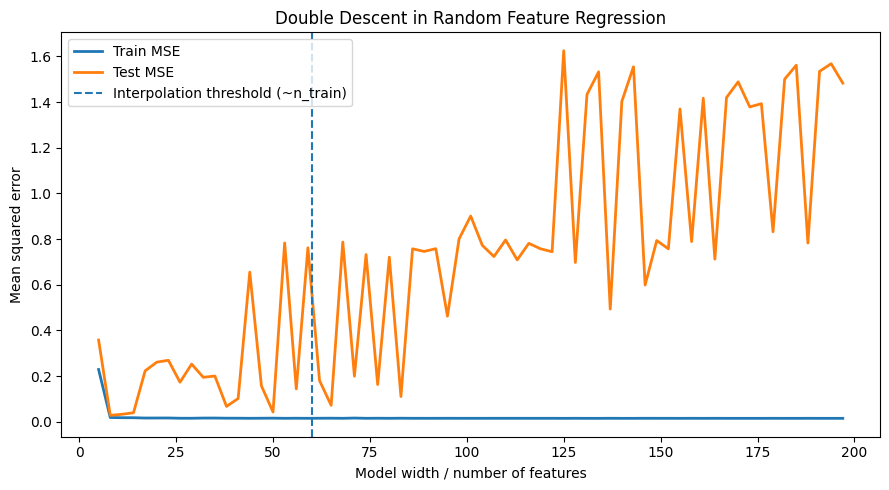

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

np.random.seed(42)

# ----------------------------
# 1. Generate synthetic data
# ----------------------------
n_samples = 120
X = np.random.uniform(-2, 2, size=(n_samples, 1))

def true_function(x):
    return np.sin(3 * x) + 0.3 * x

y_true = true_function(X[:, 0])
noise = 0.15 * np.random.randn(n_samples)
y = y_true + noise

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42
)

n_train = X_train.shape[0]

# ----------------------------
# 2. Random feature map
# ----------------------------
def random_feature_map(X, width, seed=0):
    rng = np.random.RandomState(seed)
    W = rng.normal(0, 1, size=(1, width))
    b = rng.uniform(0, 2*np.pi, size=(width,))
    return np.cos(X @ W + b)

# ----------------------------
# 3. Minimum-norm least squares
# ----------------------------
def fit_and_evaluate(width, seed=0):
    Phi_train = random_feature_map(X_train, width, seed=seed)
    Phi_test = random_feature_map(X_test, width, seed=seed)

    # Minimum norm least squares solution
    w = np.linalg.pinv(Phi_train) @ y_train

    train_pred = Phi_train @ w
    test_pred = Phi_test @ w

    train_mse = mean_squared_error(y_train, train_pred)
    test_mse = mean_squared_error(y_test, test_pred)

    return train_mse, test_mse

# ----------------------------
# 4. Sweep model width
# ----------------------------
widths = list(range(5, 200, 3))
train_errors = []
test_errors = []

for width in widths:
    tr, te = fit_and_evaluate(width, seed=width)
    train_errors.append(tr)
    test_errors.append(te)

# ----------------------------
# 5. Plot
# ----------------------------
plt.figure(figsize=(9, 5))
plt.plot(widths, train_errors, label="Train MSE", linewidth=2)
plt.plot(widths, test_errors, label="Test MSE", linewidth=2)
plt.axvline(n_train, linestyle="--", label="Interpolation threshold (~n_train)")
plt.xlabel("Model width / number of features")
plt.ylabel("Mean squared error")
plt.title("Double Descent in Random Feature Regression")
plt.legend()
plt.tight_layout()
plt.show()

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 493kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.46MB/s]


Width=10: train_acc=0.9463, test_acc=0.9071
Width=20: train_acc=0.9663, test_acc=0.9211
Width=50: train_acc=0.9915, test_acc=0.9472
Width=100: train_acc=0.9948, test_acc=0.9516
Width=200: train_acc=0.9984, test_acc=0.9544
Width=500: train_acc=0.9997, test_acc=0.9571
Width=1000: train_acc=0.9997, test_acc=0.9593


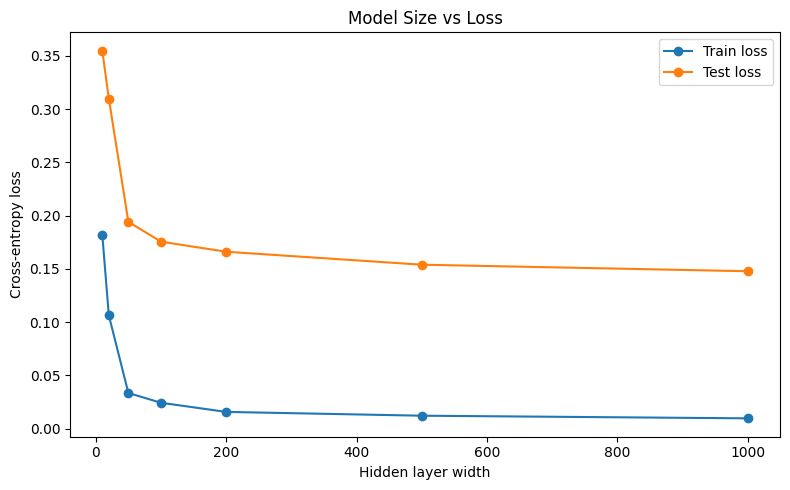

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------
# 1. Data
# ----------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])

dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_dataset, test_dataset = random_split(dataset, [10000, len(dataset) - 10000])

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

# ----------------------------
# 2. Model
# ----------------------------
class MLP(nn.Module):
    def __init__(self, width):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, width),
            nn.ReLU(),
            nn.Linear(width, 10)
        )

    def forward(self, x):
        return self.net(x)

# ----------------------------
# 3. Train + evaluate
# ----------------------------
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    loss_sum = 0
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            loss_sum += loss.item() * x.size(0)
            preds = out.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return loss_sum / total, correct / total

def train_model(width, epochs=10):
    model = MLP(width).to(device)
    optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
    criterion = nn.CrossEntropyLoss()

    for _ in range(epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

    train_loss, train_acc = evaluate(model, train_loader)
    test_loss, test_acc = evaluate(model, test_loader)
    return train_loss, train_acc, test_loss, test_acc

# ----------------------------
# 4. Sweep widths
# ----------------------------
widths = [10, 20, 50, 100, 200, 500, 1000]
train_losses, test_losses = [], []
train_accs, test_accs = [], []

for w in widths:
    tr_loss, tr_acc, te_loss, te_acc = train_model(w, epochs=10)
    train_losses.append(tr_loss)
    test_losses.append(te_loss)
    train_accs.append(tr_acc)
    test_accs.append(te_acc)
    print(f"Width={w}: train_acc={tr_acc:.4f}, test_acc={te_acc:.4f}")

# ----------------------------
# 5. Plot
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(widths, train_losses, marker='o', label="Train loss")
plt.plot(widths, test_losses, marker='o', label="Test loss")
plt.xlabel("Hidden layer width")
plt.ylabel("Cross-entropy loss")
plt.title("Model Size vs Loss")
plt.legend()
plt.tight_layout()
plt.show()